# Data analysis

In [ ]:
import duckdb

con = duckdb.connect()

df = con.execute("""
    SELECT *
    FROM read_csv_auto('/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/2019-Oct.csv')
    LIMIT 1000000
""").df()

In [7]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [ ]:
# Connect to duck db, create database file
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

# Create dbt schemas
con.execute("CREATE SCHEMA raw")
con.execute("CREATE SCHEMA staging")
con.execute("CREATE SCHEMA marts")

# Create base sample table. This lives in the "main" schema and it simulates data source (to be ingested and transformed within the dbt framework)
con.execute("""
            CREATE TABLE IF NOT EXISTS raw.events AS 
            SELECT * FROM df
            ORDER BY RAND()
            LIMIT 1000000
            """)

In [32]:
con.execute("SELECT COUNT(*) FROM raw.events").fetchall()

[(1000000,)]

In [22]:
con.execute("DROP TABLE main.events")

In [56]:
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

In [49]:
con.execute("SHOW schemas").fetchall()

ConnectionException: Connection Error: Connection already closed!

In [66]:
con.sql("SHOW tables from raw").show()

┌─────────┐
│  name   │
│ varchar │
├─────────┤
│ events  │
└─────────┘



In [64]:
con.sql("DROP VIEW main.stg_events")

In [67]:
con.close()

## Applying the A/B test

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# Get data from duck DB
con = duckdb.connect("/home/alan/alan_projects/data-project-templates/data-analysis/marketplace-analytics/data/marketplace-analytics.duckdb")

query = "SELECT * FROM marts.fct_ab_test"

df_ab = con.execute(query).df()
print(df_ab.head())

# Always close at the end of every routine
con.close()

In [ ]:
# Get A/B values

# split into A and B
df_ab = df_ab.set_index('variant')

users_A = df_ab.loc['A', 'users']
users_B = df_ab.loc['B', 'users']

conv_A = df_ab.loc['A', 'conversions']
conv_B = df_ab.loc['B', 'conversions']

cr_A = conv_A / users_A
cr_B = conv_B / users_B

uplift = (cr_B - cr_A) / cr_A

In [21]:
# Quick sanity check: Summary table
 
summary = pd.DataFrame({
    'Variant': ['A (Control)', 'B (Treatment)'],
    'Users': [users_A, users_B],
    'Conversions': [conv_A, conv_B],
    'Conversion Rate': [f"{cr_A:.3%}", f"{cr_B:.3%}"]
})
print("\nSummary table:")
print(summary)


Summary table:
         Variant  Users  Conversions Conversion Rate
0    A (Control)  81642       6095.0          7.466%
1  B (Treatment)  81382       6357.0          7.811%


In [ ]:
# Run z-test

success = [conv_A, conv_B]
nobs = [users_A, users_B]

z_stat, p_value = proportions_ztest(success, nobs)

print("\nStatistical test:")
print(f"Absolute difference: {(cr_B - cr_A)*100:.2} p.p.")
print(f"Relative uplift: {uplift*100:.2f}%")
print(f"p-value: {p_value:.4f}")

alpha = 0.01

if p_value < alpha:
    print("Result: Statistically significant at α=0.05")
else:
    print("Result: Not statistically significant at α=0.05 (expected in simulated setup)")

# This means we can "trust" the statistical diff, but in business terms, it is irrelevant. With a naive, random split, it could have gone either way.


Statistical test:
Absolute difference: 0.35 p.p.
Relative uplift: 4.63%
p-value: 0.0086
Result: Statistically significant at α=0.05


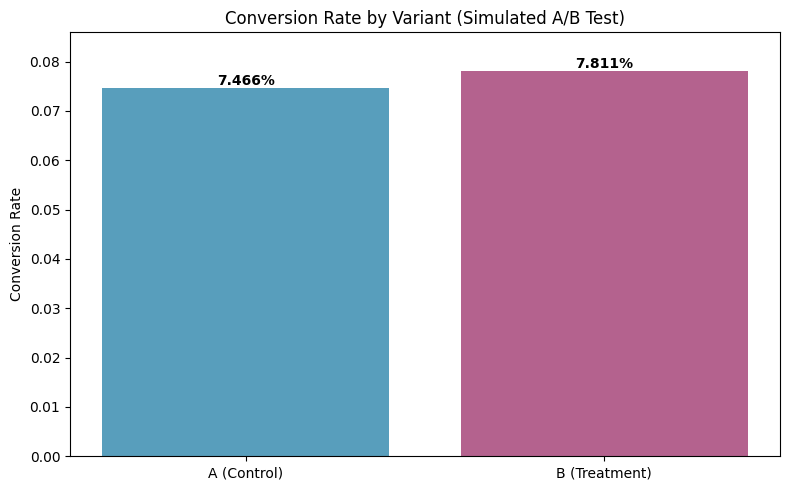

In [ ]:
# A simple, illustrative chart

plt.figure(figsize=(8, 5)) 
plt.bar(['A (Control)', 'B (Treatment)'], [cr_A, cr_B], 
        color=['#2E86AB', '#A23B72'], alpha=0.8)
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Variant (Simulated A/B Test)')
plt.ylim(0, max(cr_A, cr_B) * 1.1) 
for i, v in enumerate([cr_A, cr_B]):
    plt.text(i, v + 0.0005, f'{v:.3%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Extras

## Funnel chart

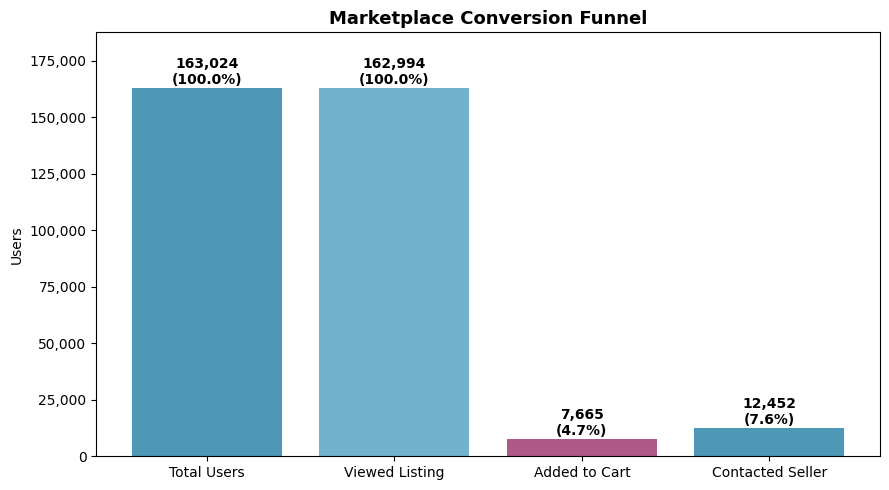

In [12]:
# === FUNNEL ANALYSIS ===
con = duckdb.connect("../data/marketplace-analytics.duckdb")

df_funnel = con.execute("SELECT * FROM marts.fct_funnel").df()
con.close()

# Aggregate safely at user level first
funnel_agg = df_funnel.groupby('user_id').agg({
    'viewed': 'max',
    'added_to_cart': 'max',
    'contacted': 'max'
}).reset_index()

funnel_steps = {
    'Total Users':      len(funnel_agg), 
    'Viewed Listing':   funnel_agg['viewed'].sum(),
    'Added to Cart':    funnel_agg['added_to_cart'].sum(),
    'Contacted Seller': funnel_agg['contacted'].sum()
}


steps = list(funnel_steps.keys())
users = list(funnel_steps.values())
drop_off = [1.0] + [users[i] / users[0] for i in range(1, len(users))]

# Chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(steps, users, color=['#2E86AB', '#5BA4C4', '#A23B72'], alpha=0.85)

# Value labels on bars
for bar, u, pct in zip(bars, users, drop_off):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(users) * 0.01,
            f'{int(u):,}\n({pct:.1%})',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Users')
ax.set_title('Marketplace Conversion Funnel', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(users) * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/funnel_chart.png', dpi=150)
plt.show()


## Segment conversion analysis

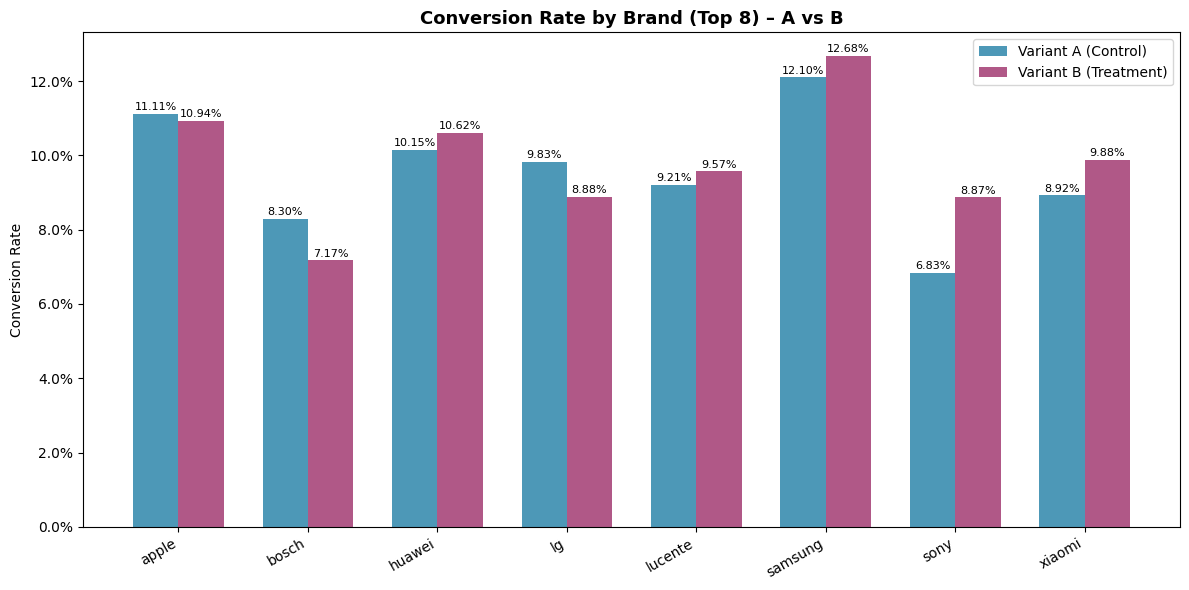

In [14]:
# === SEGMENTED A/B ANALYSIS ===
con = duckdb.connect("../data/marketplace-analytics.duckdb")

# Run dbt segment view first (or query directly)
# If you want to query the DB directly and get the results in a dataframe as in a view (easier, but not production grade)
'''
df_segment = con.execute("""
    SELECT
        s.brand AS segment,
        f.variant,
        COUNT(DISTINCT f.user_id) AS users,
        SUM(f.contacted) AS conversions,
        SUM(f.contacted) * 1.0 / COUNT(DISTINCT f.user_id) AS conversion_rate
    FROM marts.fct_funnel f
    JOIN marts.segments s ON f.user_id = s.user_id
    WHERE s.brand IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 3 DESC
""").df()
con.close()
'''

# A more robust approach is to create views in the dbt project using the view macro; these views persist for later, and here you can load as a df as well
# Run from terminal first: dbt run --select fct_ab_brand
df_segment = con.execute("SELECT * FROM marts.fct_ab_brand").df()

# Top N brands only (avoid chart clutter)
TOP_N = 8
top_brands = (
    df_segment.groupby('segment')['users']
    .sum()
    .nlargest(TOP_N)
    .index
)
df_plot = df_segment[df_segment['segment'].isin(top_brands)]

# Pivot for side-by-side bars
df_pivot = df_plot.pivot(index='segment', columns='variant', values='conversion_rate')

# Chart
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_pivot))
width = 0.35

bars_A = ax.bar([i - width/2 for i in x], df_pivot['A'], width,
                label='Variant A (Control)', color='#2E86AB', alpha=0.85)
bars_B = ax.bar([i + width/2 for i in x], df_pivot['B'], width,
                label='Variant B (Treatment)', color='#A23B72', alpha=0.85)

# Value labels
for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.2%}',
            ha='center', fontsize=8)

for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.2%}',
            ha='center', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_pivot.index, rotation=30, ha='right')
ax.set_ylabel('Conversion Rate')
ax.set_title(f'Conversion Rate by Brand (Top {TOP_N}) – A vs B', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

plt.tight_layout()
plt.savefig('../data/segment_chart.png', dpi=150)
plt.show()
